## **1. Préliminaires**

### **1.1. Contexte**
Nous pratiquons dans ce notebook l'analyse de données sur les données provenant d'un dataset `heart attack prediction` de [Kaggle](https://kaggle.com/datasets).
Nous allons dans ce notebook explorer , visualiser et interpreter nos variables.

### **1.2. Imports des librairies**

Dans cette section nous allons importer les librairies principales .

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **1.3. Chargement des données**
Nous allons maintenant charger notre dataset .

In [2]:
# chargement du dataset
data = pd.read_csv('../data/data-cleaned.csv')

# affichage d'un extrait
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,0
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,0
2,29,1,2,140.0,243.0,0.0,0.0,170.0,0.0,0.0,0
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,0
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,0


### **1.4. Structure et typologie des données**
Nous allons analyser la structure de notre jeu de données et le types des données et changer les types de données si nécessaires.

In [3]:
# dimension du dataset
data.shape

(284, 11)

In [4]:
# affichage des infos sur les variables et leurs types
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284 entries, 0 to 283
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       284 non-null    int64  
 1   sex       284 non-null    int64  
 2   cp        284 non-null    int64  
 3   trestbps  284 non-null    float64
 4   chol      284 non-null    float64
 5   fbs       284 non-null    float64
 6   restecg   284 non-null    float64
 7   thalach   284 non-null    float64
 8   exang     284 non-null    float64
 9   oldpeak   284 non-null    float64
 10  num       284 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 24.5 KB


## **2. Analyse Exploratoire des données**

### **2.1. Analyse univariée**

Nous allons observer la distribution de chaque variable

#### **2.1.1. la variable `age`**

Ici nous allons exposer quelques graphiques qui montrent la distribution de la variable **age**.

In [5]:
# discretisation de la variable âge
age_bins = pd.cut(data['age'],bins=np.arange(20,80,10)).value_counts().reset_index()

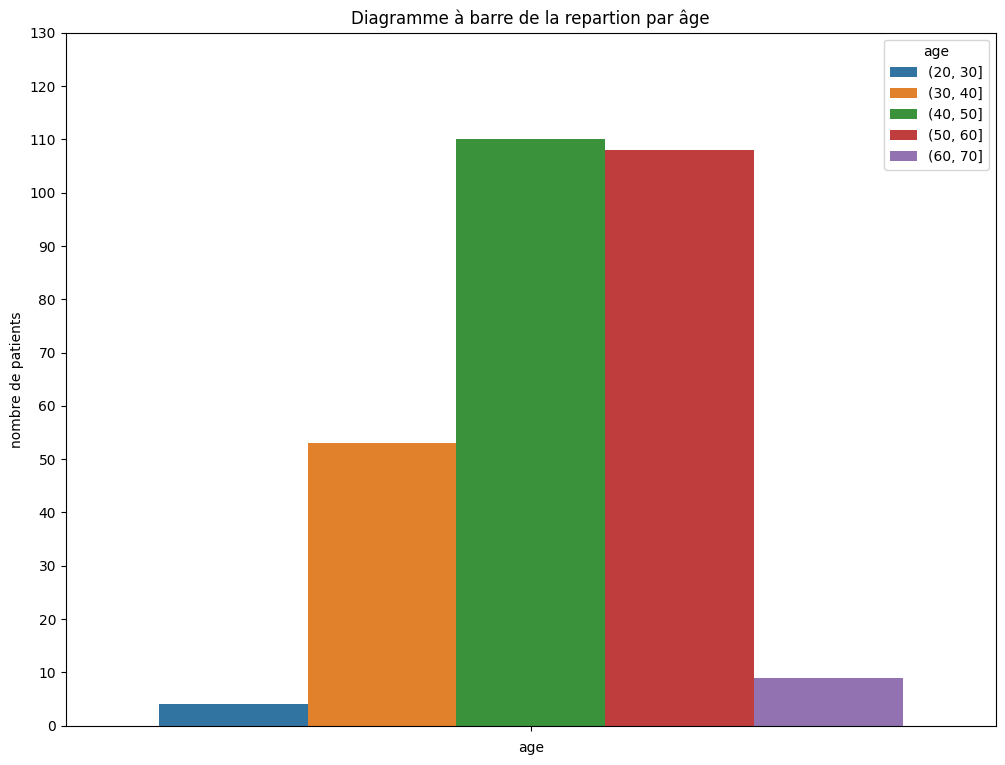

In [6]:
# diagramme à barre de la repartition par âge
plt.figure(figsize=(12,9))
sns.barplot(data=age_bins,hue='age',y='count',errorbar=None)
plt.ylabel('nombre de patients')
plt.xlabel('age')
plt.yticks(ticks=np.arange(0,140,10))
plt.title('Diagramme à barre de la repartion par âge')
plt.show()

**Interprétation** 

On remarque que la majorité des patients sont dans la tranche  entre 40 et 60 ans avec une minorité pour les tranche 20 à 30 et 60 à 70.

#### **2.1.2. la variable `num`**

In [7]:
# le compte des patients
num_counts = data['num'].value_counts().reset_index()
# labelisation
num_counts.replace({"num": {0: "malade", 1: "sain"}},inplace=True)["num"].astype("category")

# les couleurs
num_colors = sns.color_palette(palette="viridis", n_colors=num_counts["num"].nunique())

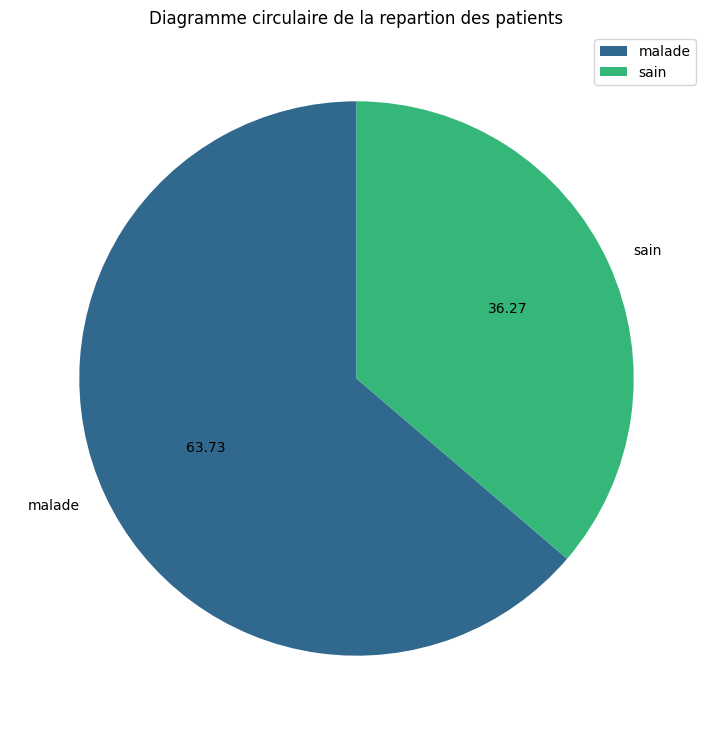

In [24]:
# Diagramme circulaire de la repartion des patients

plt.figure(figsize=(12,9))

plt.pie(x=num_counts['count'],labels=num_counts['num'],colors=num_colors,startangle=90,autopct="%2.2f")

plt.legend()
plt.title("Diagramme circulaire de la repartion des patients")
plt.show()

**interprétation** : 

Notre dataset est majoritairement composé de patients malades.

#### **2.1.3. la variable `cp`**

In [9]:
# le compte par modalité
cp_counts = data['cp'].value_counts().reset_index()
# labelisation
labels ={
    1: "Angine typique",
    2 :"Angine atypique",
    3 : "Douleur non angineuse",
    4 : "Asymptomatique"
}
cp_counts.replace({'cp':labels},inplace=True)

,cp,count
0,Asymptomatique,120
1,Angine atypique,102
2,Douleur non angineuse,52
3,Angine typique,10


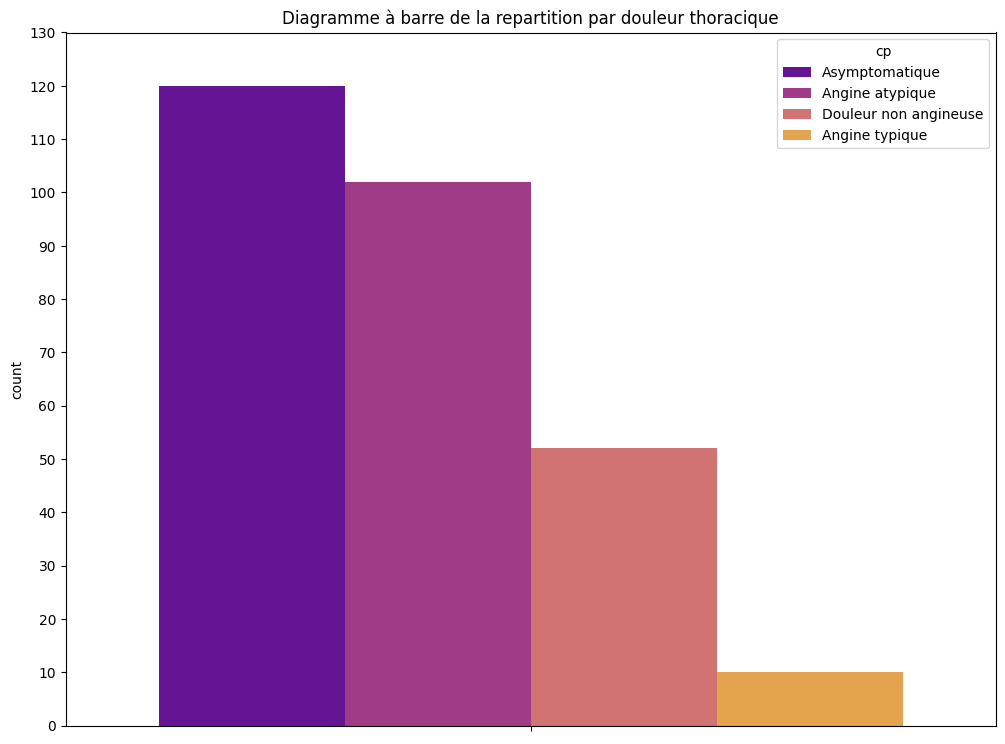

In [16]:
# graphique de barplot pour la répartion de cp
plt.figure(figsize=(12,9))

sns.barplot(data=cp_counts,y='count',hue='cp',palette='plasma')

plt.yticks(ticks=np.arange(0,140,10))

plt.title("Diagramme à barre de la repartition par douleur thoracique")

plt.show()

**interprétation** : 
On remarque que le cas `asymptomatique` est majoritaire suivi par les indidividus du cas `Angine atypique` .

Le cas `Anginge typique` reste le plus sous représentée suivi du cas `Douleur non angineuse`.